### Question: Is there an association between the number of hours spent on homework per week and the level of academic pressure experienced by adolescents?

#### Study type: Observational study. The file consists of results from questionnaires conducted among 500 students from the USA, and it is a sample and not a whole population, so it cannot be considered as a census.

## Load data

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

def to_hours(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s == "":
        return np.nan
    minutes = "min" in s
    s = re.sub(r"[a-z\s]+", "", s)
    try:
        if "/" in s:
            a, b = s.split("/")
            v = float(a) / float(b)
        elif "-" in s:
            a, b = s.split("-")
            v = (float(a) + float(b)) / 2
        else:
            v = float(s)
    except ValueError:
        return np.nan
    return v / 60 if minutes else v

raw = pd.read_csv("CensusAtSchool.csv")
df = raw.copy()
df["Homework"] = df["Doing_Homework_Hours"].apply(to_hours)
df["Age"] = pd.to_numeric(df["Ageyears"], errors="coerce")
order = ["Very little", "Some", "A lot"]
df["Pressure"] = pd.Categorical(df["Schoolwork_Pressure"], categories=order, ordered=True)
df["Pressure_code"] = df["Pressure"].cat.codes.replace(-1, np.nan)

data = df.dropna(subset=["Homework", "Pressure"])
data = data[(data["Age"] >= 10) & (data["Age"] <= 19)]
data = data[(data["Homework"] >= 0) & (data["Homework"] <= 70)].reset_index(drop=True)

print(f"Students analysed: {len(data)} (out of {len(raw)} survey responses)")

Students analysed: 408 (out of 500 survey responses)


## Homework hours

In [2]:
summary = data.groupby("Pressure", observed=True)["Homework"].agg(
    Students="count", Mean="mean", Median="median", Std="std"
).round(2)
summary

,Students,Mean,Median,Std
Pressure,,,,
Very little,57,4.01,2.0,4.70
Some,188,7.26,5.0,8.34
A lot,163,10.97,9.0,10.14


## Average homework hours

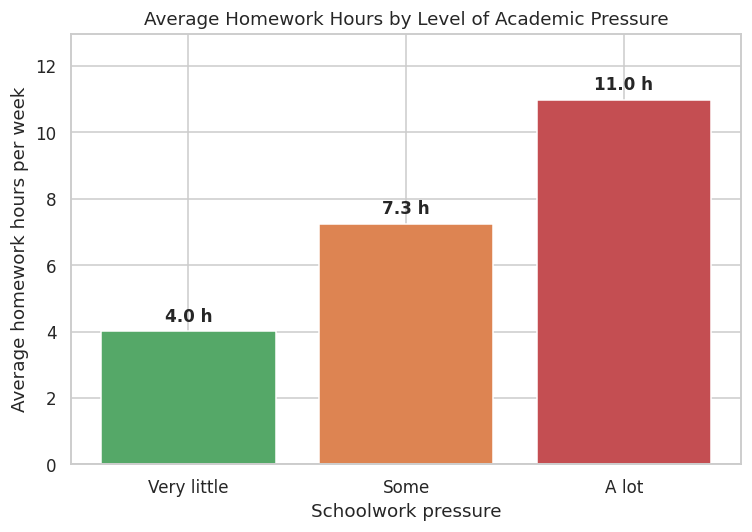

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

colors = ["#55A868", "#DD8452", "#C44E52"]
means = data.groupby("Pressure", observed=True)["Homework"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(order, means.values, color=colors)
ax.bar_label(bars, fmt="%.1f h", padding=4, fontsize=11, fontweight="bold")
ax.set_title("Average Homework Hours by Level of Academic Pressure")
ax.set_xlabel("Schoolwork pressure")
ax.set_ylabel("Average homework hours per week")
ax.set_ylim(0, means.max() + 2)
plt.tight_layout()
plt.show()

## How pressure changes as homework hours go up

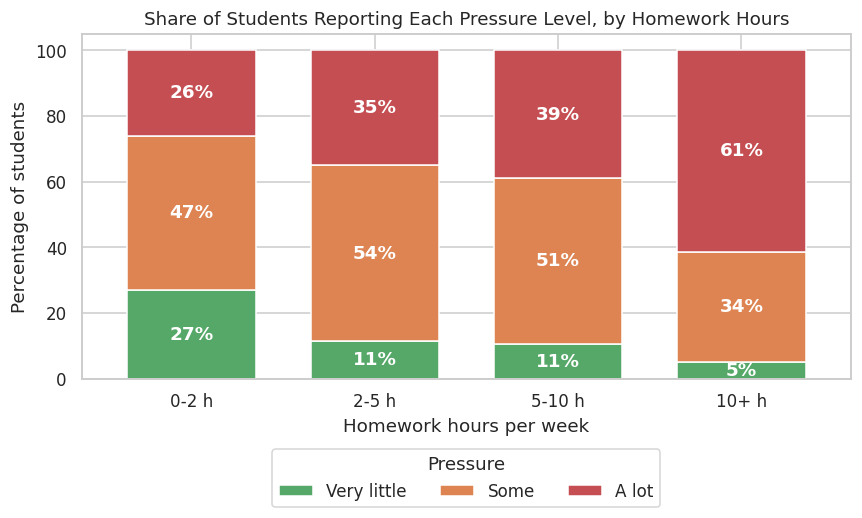

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

colors = ["#55A868", "#DD8452", "#C44E52"]
bins = [-0.01, 2, 5, 10, 70]
labels = ["0-2 h", "2-5 h", "5-10 h", "10+ h"]
group = pd.cut(data["Homework"], bins=bins, labels=labels)
share = pd.crosstab(group, data["Pressure"], normalize="index").reindex(columns=order) * 100

fig, ax = plt.subplots(figsize=(8, 5))
share.plot(kind="bar", stacked=True, color=colors, ax=ax, edgecolor="white", width=0.7)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", label_type="center", color="white", fontweight="bold")
ax.set_title("Share of Students Reporting Each Pressure Level, by Homework Hours")
ax.set_xlabel("Homework hours per week")
ax.set_ylabel("Percentage of students")
ax.legend(title="Pressure", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

Yes, there is a positive correlation between number of hours spent on homework per week and academic pressure in adolescents. Those who spend more hours on homework are more stressed. Since it is an observational study, increased time spent on homework does not mean increased pressure. Also, increased academic pressure may result in increased time spending on homework, or there may be another variable influencing both.
All responses were self-reported; homework data was collected in free-text form and coded numerically.
This study includes 500 students who voluntarily took the questionnaire, hence the results cannot be generalized for all American adolescents.
According to the data above, the more hours American adolescents spend doing their homework per week, the more academic pressure they experience.